### Task-1

Fine-tune an object detection model such as YOLO to detect and classify custom real-world objects captured using mobile devices that are not adequately recognized by pre-trained models.

To complete the assignment, perform the following tasks:

Collect a custom image dataset containing the target objects captured under different real-world conditions such as varying illumination, background complexity, viewing angles, occlusion, and object scales.

Annotate the dataset using appropriate bounding-box annotations and divide it into training, validation, and testing sets.

Apply suitable data augmentation techniques to improve the robustness and generalization capability of the model.

Fine-tune a pre-trained object detection model on the custom dataset.

Evaluate the performance of the fine-tuned model using standard object detection metrics, including:

Precision

Recall

Mean Average Precision (mAP)

Inference speed and detection latency

Analyze the strengths and limitations of the developed detector and compare its performance with the original pre-trained model on the custom object categories.

The report should include:

Dataset preparation and annotation methodology

Model architecture and training configuration

Data augmentation strategies

Experimental results and performance analysis

Qualitative detection examples

Discussion and conclusion



In [ ]:
from ultralytics import YOLO
import os

# Load pre-trained YOLOv8n model
model = YOLO("yolov8n.pt")   # Nano version - best for CPU

# Fine-tune
results = model.train(
    data="/home/saidul/Desktop/4-2/Deep Learning/data/monitor_detection/data.yaml",
    epochs=50,                  # You can increase to 100 later
    imgsz=640, # Standard size for YOLOv8: 640x640 px
    batch=8,               # Small batch for CPU
    name="monitor_detector",
    patience=20,
    augment=True,
    device='cpu'
)

print("Training completed!")

Ultralytics 8.4.51 🚀 Python-3.12.3 torch-2.12.0+cu130 CPU (Intel Core i7-8665U 1.90GHz)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/home/saidul/Desktop/4-2/Deep Learning/data/monitor_detection/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=monitor_detector, nbs=64, nms=False, opset=None, optimize=

In [4]:
# Evaluate on test set
metrics = model.val()

# Run inference on test images
results = model.predict(source="/home/saidul/Desktop/4-2/Deep Learning/data/monitor_detection/images/test", save=True, conf=0.25)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.51 🚀 Python-3.12.3 torch-2.12.0+cu130 CPU (Intel Core i7-8665U 1.90GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1588.6±435.2 MB/s, size: 113.0 KB)
val: Scanning /home/saidul/Desktop/4-2/Deep Learning/data/monitor_detection/labels/val.cache... 6 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 6/6 1.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.6s/it 2.6s
                   all          6         13      0.841      0.923      0.912      0.852
Speed: 5.7ms preprocess, 352.4ms inference, 0.0ms loss, 22.7ms postprocess per image
Results saved to /home/saidul/Desktop/4-2/Deep Learning/runs/detect/val-2

image 1/5 /home/saidul/Desktop/4-2/Deep Learning/data/monitor_detection/images/test/photo_22_2026-05-17_14-26-44_jpg.rf.XRpRV4KvI7zSOj2h0qTe.jpg: 480x640 2 monitors, 302.4ms
image 2/5 /home/saidul/Desktop/4-2/Deep Learning/data/monitor_detection/images/test/photo_25_2026-05-17_14-26-4


image 1/5 /home/saidul/Desktop/4-2/Deep Learning/data/monitor_detection/images/test/photo_22_2026-05-17_14-26-44_jpg.rf.XRpRV4KvI7zSOj2h0qTe.jpg: 480x640 2 monitors, 132.2ms
image 2/5 /home/saidul/Desktop/4-2/Deep Learning/data/monitor_detection/images/test/photo_25_2026-05-17_14-26-44_jpg.rf.b5EpI0LpzIoQJIzBa78u.jpg: 640x480 1 monitor, 95.5ms
image 3/5 /home/saidul/Desktop/4-2/Deep Learning/data/monitor_detection/images/test/photo_2_2026-05-17_14-26-44_jpg.rf.zJwVgbMk9QaF8l12diLR.jpg: 480x640 2 monitors, 90.7ms
image 4/5 /home/saidul/Desktop/4-2/Deep Learning/data/monitor_detection/images/test/photo_31_2026-05-17_14-26-44_jpg.rf.lvF7STvxKJIs1xFqm1qD.jpg: 640x480 2 monitors, 122.9ms
image 5/5 /home/saidul/Desktop/4-2/Deep Learning/data/monitor_detection/images/test/photo_4_2026-05-17_14-26-44_jpg.rf.2GElnR4rEvENvfnh5YfE.jpg: 640x480 3 monitors, 174.6ms
Speed: 3.5ms preprocess, 123.2ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /home/saidul/Deskto

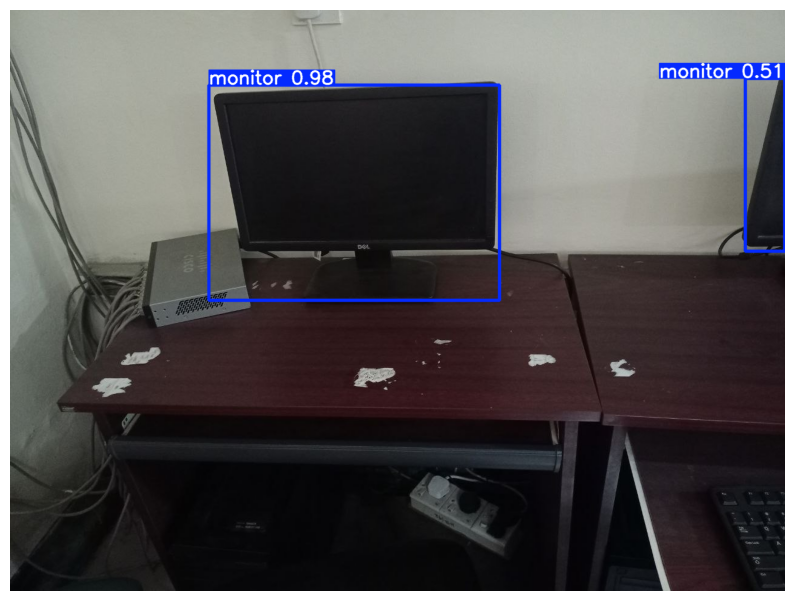

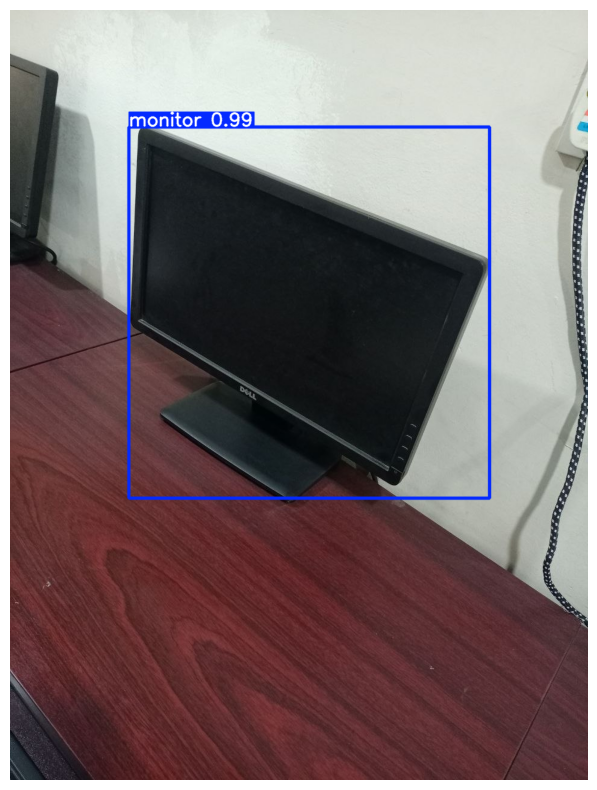

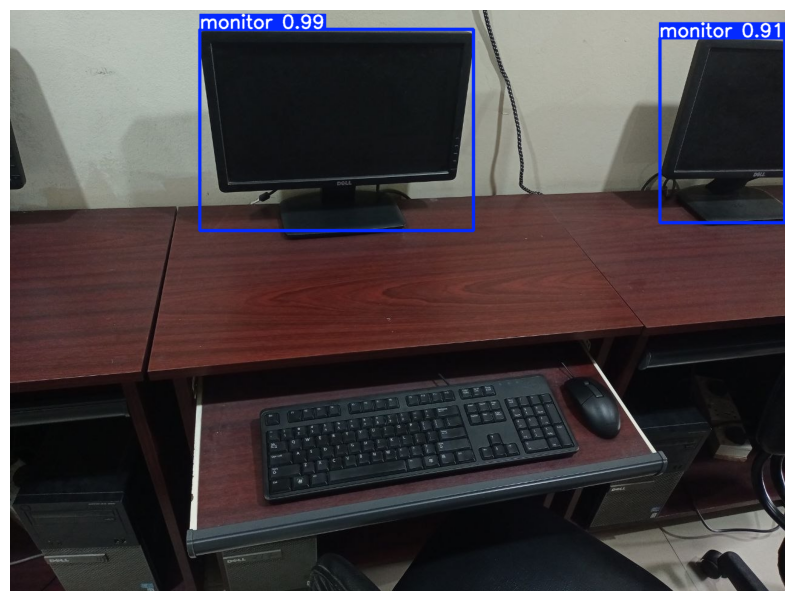

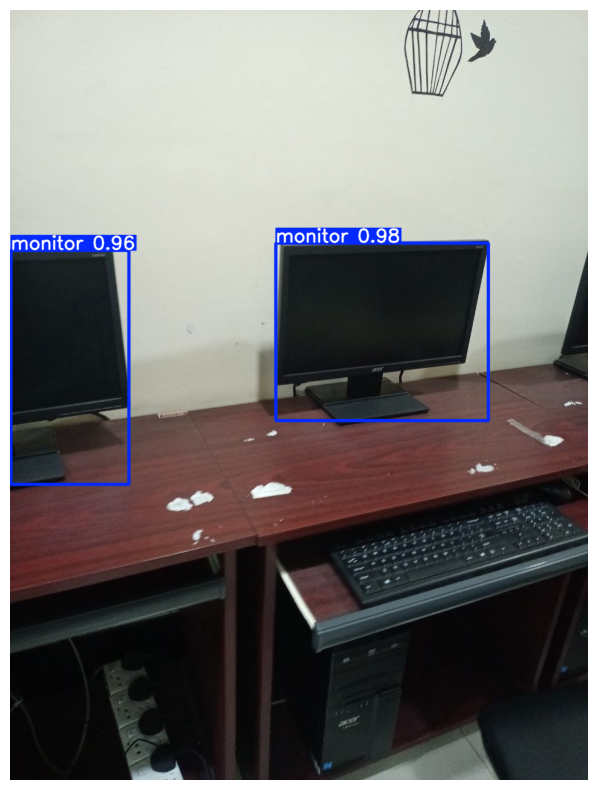

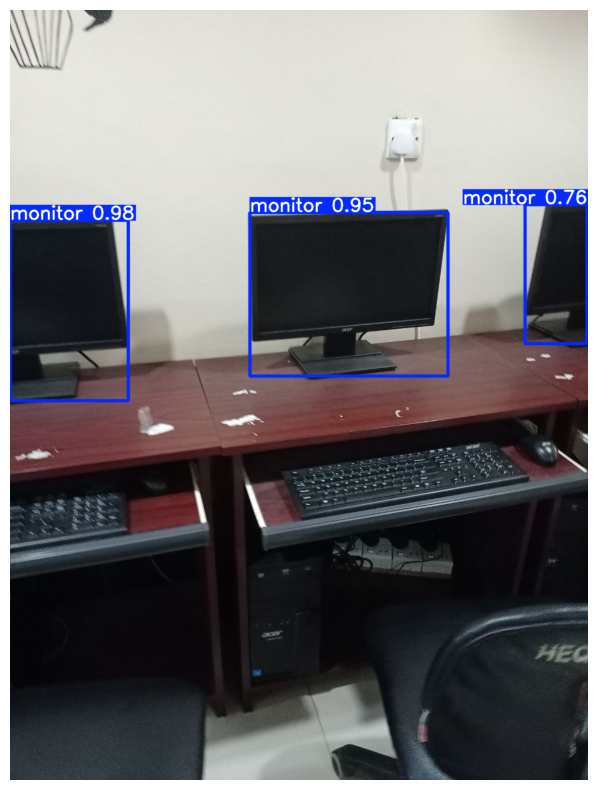

In [14]:
import cv2
import matplotlib.pyplot as plt

results = model.predict("/home/saidul/Desktop/4-2/Deep Learning/data/monitor_detection/images/test", save=True, conf=0.3)

for img_result in results:
    annotated_img = img_result.plot()
    rgb_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(rgb_img)
    plt.axis('off')
    plt.show()
